<a href="https://colab.research.google.com/github/CodeSage54/Deep-Learning/blob/main/FNN_ImageRecognition/Fashion_MNIST_FNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement:**

Fashion MNIST is a dataset comprising 60,000 training images and 10,000 testing images, each depicting various fashion items in a 28x28 grayscale format. The dataset encompasses ten distinct categories of apparel. The primary aim of this assignment is to develop a fully connected neural network (FCNN) that can accurately classify these images into the correct fashion categories.


**Objectives:**

**Data Visualization and Preprocessing:**

● Visualize the distribution of different fashion items in the dataset to understand the data better.

● Normalize the image pixel values for effective model training.

● Convert the categorical labels into a one-hot encoded format to suit the neural network’s output layer.

**Model Architecture and Development:**

● Design a fully connected neural network with appropriate input, hidden, and output layers.

● Ensure the model is complex enough to capture the underlying patterns in the data without overfitting.

**Model Training:**

● Train the model on the preprocessed training data, using categorical cross-entropy as the loss function, stochastic gradient descent as the optimizer, and accuracy as the evaluation metric.

● Utilize a validation split to monitor the model’s performance on unseen data during training.

**Performance Evaluation:**

● Assess the model’s performance using both training and validation datasets.

● Visualize the training and validation loss and accuracy to identify any signs of overfitting or underfitting.


In [99]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import fashion_mnist


In [100]:
#load the fashion mnist dataset
(x_train, y_train), (x_test,y_test) = fashion_mnist.load_data()

In [101]:
print("Training Data :", x_train.shape)
print("Training Labels:", y_train.shape)
print("Test Data:", x_test.shape)
print("Test Labels:", y_test.shape)


Training Data : (60000, 28, 28)
Training Labels: (60000,)
Test Data: (10000, 28, 28)
Test Labels: (10000,)


Based on the Shape above, training data consists of 60,000 images each being  28 * 28 dimension. The testing data consists of 10,000 images of 28 * 28 dimension.

In [102]:
# Find unique labels
unique_labels = set(map(int, y_train))
print("Unique labels:", unique_labels)
print("Number of categories:", len(unique_labels))


Unique labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
Number of categories: 10


**Visualize the unique labels in the dataset**

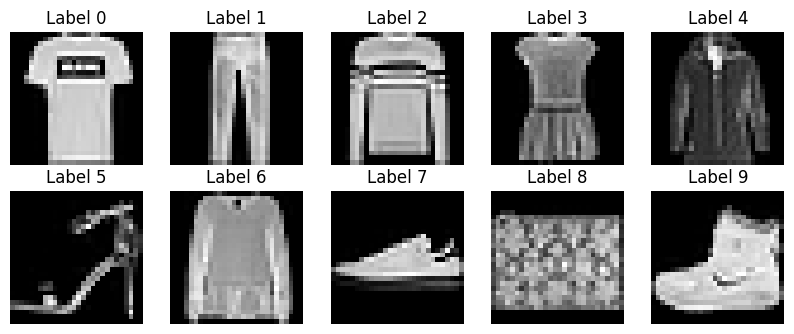

In [116]:
# for each value in Unique label, pick one index in x_train that has the same value
# Visualize all 10 category images
plt.figure(figsize=(10,10))
for label in unique_labels:
  plt.subplot(5,5,label+1)
  index = np.where(y_train == label)[0][0]
  plt.title(f"Label {label}")
  plt.imshow(x_train[index], cmap='gray')
  plt.axis('off')
plt.show()

In [104]:
# Lets map the numeric labels to custom string labels based on above visual output.
label_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [105]:
# normalize

train_x = x_train/255.0
test_x =  x_test/255.0

In [106]:
#flatten
train_x = train_x.reshape(-1,784)
test_x = test_x.reshape(-1,784)

In [107]:
print("Train shape:", train_x.shape)
print("Test shape:", test_x.shape)


Train shape: (60000, 784)
Test shape: (10000, 784)


In [108]:
# One hot encoding
train_y = to_categorical(y_train, num_classes=10)
test_y = to_categorical(y_test, num_classes=10)

**Model Architecture**

***Key Design Choices***
- Input layer: 784 neurons (since each image is 28×28 = 784 features).
- Hidden layers: Dense layers with ReLU activation.
- First hidden layer: 256 neurons (captures complex patterns).
- Second hidden layer: 128 neurons (reduces dimensionality, balances complexity).
- Output layer: 10 neurons with softmax activation (one per fashion category).


In [109]:
#create a model
model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)), # Input + First Hidden Layer
    Dense(128, activation='relu'), # Second Hidden Layer
    Dense(10, activation='softmax') # Output Layer
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
#compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)


In [111]:
# Train the model for 25 EPOCHS.
# Reserve 20% data to validate against unseen data.
history = model.fit(
    train_x, train_y,
    epochs=25,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

Epoch 1/25
375/375 - 3s - 8ms/step - accuracy: 0.6506 - loss: 1.1735 - val_accuracy: 0.7461 - val_loss: 0.7576
Epoch 2/25
375/375 - 2s - 7ms/step - accuracy: 0.7705 - loss: 0.6845 - val_accuracy: 0.7924 - val_loss: 0.6176
Epoch 3/25
375/375 - 3s - 8ms/step - accuracy: 0.7994 - loss: 0.5899 - val_accuracy: 0.7987 - val_loss: 0.5687
Epoch 4/25
375/375 - 2s - 6ms/step - accuracy: 0.8142 - loss: 0.5416 - val_accuracy: 0.8152 - val_loss: 0.5267
Epoch 5/25
375/375 - 2s - 6ms/step - accuracy: 0.8248 - loss: 0.5102 - val_accuracy: 0.8255 - val_loss: 0.4979
Epoch 6/25
375/375 - 2s - 6ms/step - accuracy: 0.8325 - loss: 0.4883 - val_accuracy: 0.8307 - val_loss: 0.4812
Epoch 7/25
375/375 - 2s - 6ms/step - accuracy: 0.8362 - loss: 0.4726 - val_accuracy: 0.8359 - val_loss: 0.4711
Epoch 8/25
375/375 - 3s - 7ms/step - accuracy: 0.8417 - loss: 0.4591 - val_accuracy: 0.8402 - val_loss: 0.4603
Epoch 9/25
375/375 - 3s - 7ms/step - accuracy: 0.8440 - loss: 0.4487 - val_accuracy: 0.8443 - val_loss: 0.4467
E

**Model Performance Monitoring**

In [112]:
test_loss, test_acc = model.evaluate(test_x, test_y, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.8499
Test Loss: 0.4242


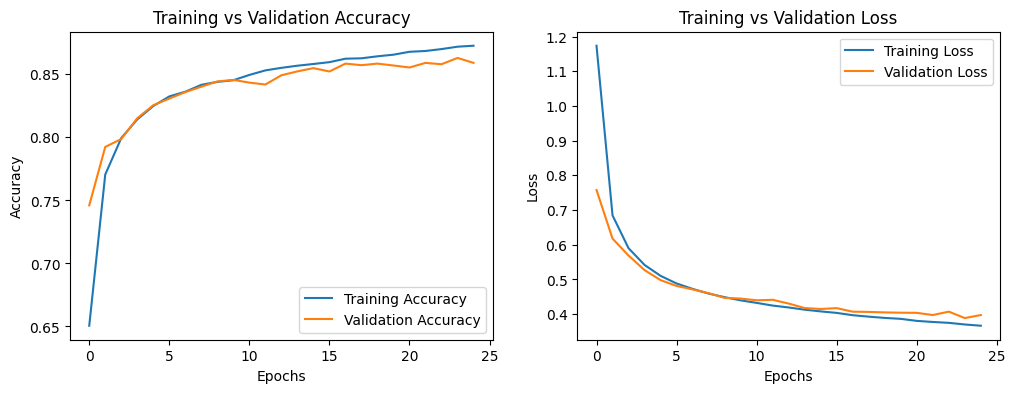

In [113]:
# Plot Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Both Training Accuracy and Validation Accuracy improve together. Same is the case with Training Loss vs Validation loss. Indicating that the model is not overfitting and is learning well.

**Test the model on a random object chosen from the dataset**


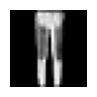

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Actual Label value:  1
Actual Label String:  Trouser
Predicted:  Trouser


In [115]:
plt.figure(figsize=(1,1))

i=3 #random index to search on

img = test_x[i].reshape(28,28)
plt.imshow(img,cmap = "gray")
plt.axis("off")
plt.show()
pred = model.predict(test_x[i:i+1]) # pred will be of shape (1,10). one row (the batch), 10 columns (class probabilities)
pred_label = int(np.argmax(pred[0])) # returns the index with the highest probability

print("Actual Label value: ", int(y_test[i]))
print("Actual Label String: ", label_map[int(y_test[i])])
print("Predicted: ", label_map[pred_label])